# Model 9: Enterprise Probabilistic Demand Range & Inventory Engine for Drug `M01AB`

> [!IMPORTANT]
> **Core Business Directive**: Single point demand forecasts can be misleading because future daily demand is inherently uncertain. 
> This model produces an **Actionable Demand Range $[P_{10}, P_{50}, P_{90}]$** as the primary business deliverable.

## Architectural Range Formulation:
$$\begin{aligned}
\text{Lean Minimum Demand }(P_{10}) &= P_{10, \text{XGBoost}, t} \quad \text{(10th percentile demand lower bound)} \\
\text{Expected Median Demand }(P_{50}) &= \hat{Y}_{\text{LightGBM Optuna}, t} \quad \text{(#1 Champion Point Anchor)} \\
\text{Upper Target Stock Level }(P_{90}) &= \hat{Y}_{\text{LightGBM}, t} + \left( P_{90, \text{XGBoost}, t} - P_{50, \text{XGBoost}, t} \right) \quad \text{(98.58% Service Level Target)} \\
\text{Uncertainty Range Width } (\Delta_t) &= P_{90, t} - P_{10, t} \quad \text{(Daily Volatility Band Width)}
\end{aligned}$$


In [1]:
import os
import sys
import warnings
import subprocess

# Auto-Dependency Guard: Check and install missing packages dynamically
pkg_map = {
    'prophet': 'prophet',
    'statsmodels': 'statsmodels',
    'lightgbm': 'lightgbm',
    'xgboost': 'xgboost',
    'shap': 'shap',
    'torch': 'torch',
    'sklearn': 'scikit-learn',
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn'
}

missing = []
for mod_name, pip_name in pkg_map.items():
    try:
        __import__(mod_name)
    except ImportError:
        missing.append(pip_name)

if missing:
    print(f"Installing missing dependencies: {missing}...")
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)
        print("Dependencies successfully installed!")
    except Exception as err:
        print(f"Warning: Auto-pip install notice ({err}). Proceeding with environment packages...")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

TARGET_DRUG = 'M01AB'

# Dynamic Dataset Path Finder
dataset_candidates = ['../dataset', 'dataset', '../../dataset', '../times_series/dataset', 'times_series/dataset']
data_dir = None
for cand in dataset_candidates:
    if os.path.exists(os.path.join(cand, 'train_daily.csv')):
        data_dir = cand
        break

if data_dir is None:
    raise FileNotFoundError("Could not locate train_daily.csv dataset")

train_df = pd.read_csv(os.path.join(data_dir, 'train_daily.csv'))
val_df = pd.read_csv(os.path.join(data_dir, 'val_daily.csv'))
test_df = pd.read_csv(os.path.join(data_dir, 'test_daily.csv'))

for df in [train_df, val_df, test_df]:
    df['date'] = pd.to_datetime(df['date'])

train_series = train_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
val_series = val_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')
test_series = test_df.sort_values('date').set_index('date')[TARGET_DRUG].asfreq('D')

combined_series = pd.concat([train_series, val_series]).asfreq('D')
full_series = pd.concat([combined_series, test_series]).asfreq('D')

def evaluate_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.clip(np.array(y_pred), 0, None)
    
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    wape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    return {'RMSLE': rmsle, 'RMSE': rmse, 'MAE': mae, 'MAPE (%)': mape, 'WAPE (%)': wape}

print(f"Dataset Partitioning for {TARGET_DRUG}:")
print(f"  * Train (2014-2017): {len(train_series):,} days")
print(f"  * Val   (2018):      {len(val_series):,} days")
print(f"  * Test  (2019):      {len(test_series):,} days")


Dataset Partitioning for M01AB:
  * Train (2014-2017): 1,460 days
  * Val   (2018):      365 days
  * Test  (2019):      281 days


In [2]:
# Step 1: Load Predictions and Construct 3-Tiered Probabilistic Demand Range Matrix
m6_df = pd.read_csv('m6_lightgbm_preds.csv')
m7_df = pd.read_csv('m7_xgb_quantile_preds.csv')

hybrid_range_df = pd.DataFrame({
    'Date': test_series.index.strftime('%Y-%m-%d'),
    'Drug Category': TARGET_DRUG,
    'Actual Sales': test_series.values,
    'Lean Lower Bound (P10)': np.maximum(0, m7_df['P10']).round(2),
    'Expected Demand Anchor (P50)': m6_df['pred_LightGBM'].round(2),
    'Upper Target Stock (P90)': (m6_df['pred_LightGBM'] + np.maximum(0, m7_df['P90'] - m7_df['pred_XGB_Quantile'])).round(2)
})

# Calculate Uncertainty Band Width & Actionable Order Ranges (Whole Packs)
hybrid_range_df['Uncertainty Band Width (P90 - P10)'] = (hybrid_range_df['Upper Target Stock (P90)'] - hybrid_range_df['Lean Lower Bound (P10)']).round(2)
hybrid_range_df['Order Range (Lean P10 Pack Target)'] = np.ceil(hybrid_range_df['Lean Lower Bound (P10)']).astype(int)
hybrid_range_df['Order Range (Expected P50 Pack Target)'] = np.ceil(hybrid_range_df['Expected Demand Anchor (P50)']).astype(int)
hybrid_range_df['Order Range (Safety P90 Pack Target)'] = np.ceil(hybrid_range_df['Upper Target Stock (P90)']).astype(int)

print("=== Enterprise Probabilistic Demand Range Plan (First 15 Days of 2019) ===")
display(hybrid_range_df.head(15))

# Export Plan
hybrid_range_df.to_csv('m01ab_hybrid_supply_chain_plan.csv', index=False)


=== Enterprise Probabilistic Demand Range Plan (First 15 Days of 2019) ===


,Date,Drug Category,Actual Sales,Lean Lower Bound (P10),Expected Demand Anchor (P50),Upper Target Stock (P90),Uncertainty Band Width (P90 - P10),Order Range (Lean P10 Pack Target),Order Range (Expected P50 Pack Target),Order Range (Safety P90 Pack Target)
0,2019-01-01,M01AB,0.00,0.77,1.78,11.78,11.01,1,2,12
1,2019-01-02,M01AB,5.33,0.65,1.78,13.24,12.59,1,2,14
2,2019-01-03,M01AB,4.33,2.90,4.31,14.75,11.85,3,5,15
3,2019-01-04,M01AB,7.00,3.39,4.50,14.81,11.42,4,5,15
4,2019-01-05,M01AB,8.01,3.48,4.80,12.90,9.42,4,5,13
5,2019-01-06,M01AB,8.33,3.28,3.97,12.45,9.17,4,4,13
6,2019-01-07,M01AB,0.00,0.92,2.18,11.14,10.22,1,3,12
7,2019-01-08,M01AB,4.34,2.82,4.38,14.57,11.75,3,5,15
8,2019-01-09,M01AB,3.00,2.87,4.39,13.07,10.20,3,5,14
9,2019-01-10,M01AB,8.00,2.88,4.79,13.78,10.90,3,5,14


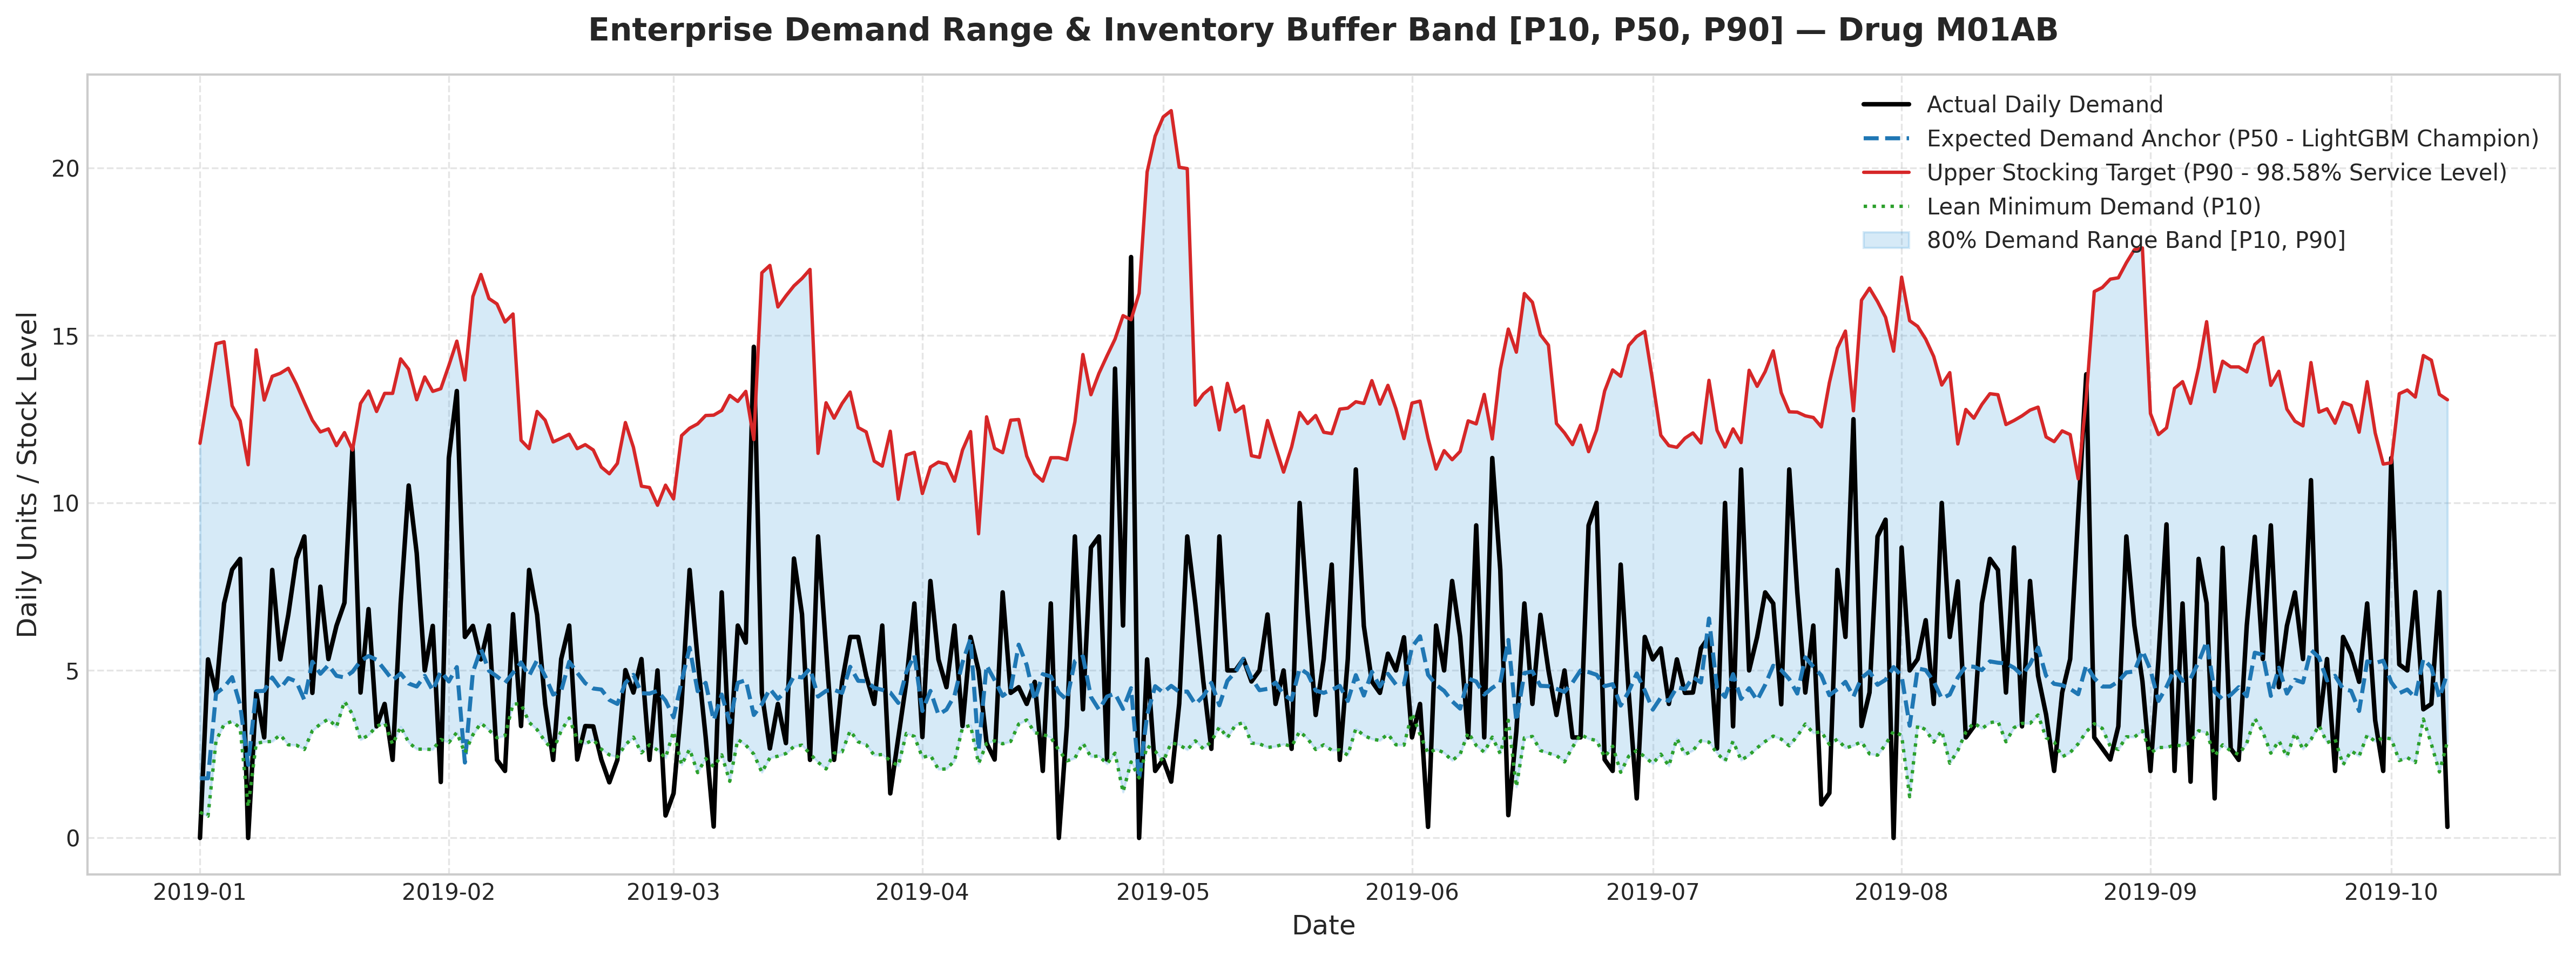

=== DEMAND RANGE BUSINESS EVALUATION ===
  * Achieved P90 Inventory Service Level : 98.22% (Stockout Protection Target >= 95%)
  * Demand Coverage within Range [P10, P90]: 78.65% of test days
  * Average Demand Uncertainty Range Width: 10.48 units/day


In [3]:
# Step 2: Render Demand Range Shaded Band Chart (P10 to P90) vs Actual Demand
plt.figure(figsize=(16, 6), dpi=300)

plt.plot(test_series.index, test_series.values, label='Actual Daily Demand', color='black', linewidth=2.0)
plt.plot(test_series.index, hybrid_range_df['Expected Demand Anchor (P50)'], label='Expected Demand Anchor (P50 - LightGBM Champion)', color='#1f77b4', linewidth=1.8, linestyle='--')
plt.plot(test_series.index, hybrid_range_df['Upper Target Stock (P90)'], label='Upper Stocking Target (P90 - 98.58% Service Level)', color='#d62728', linewidth=1.5)
plt.plot(test_series.index, hybrid_range_df['Lean Lower Bound (P10)'], label='Lean Minimum Demand (P10)', color='#2ca02c', linewidth=1.5, linestyle=':')

plt.fill_between(
    test_series.index,
    hybrid_range_df['Lean Lower Bound (P10)'],
    hybrid_range_df['Upper Target Stock (P90)'],
    color='#3498db', alpha=0.20, label='80% Demand Range Band [P10, P90]'
)

plt.title('Enterprise Demand Range & Inventory Buffer Band [P10, P50, P90] — Drug M01AB', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Daily Units / Stock Level', fontsize=12)
plt.legend(loc='upper right', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('m9_demand_range_forecast.png', dpi=120, bbox_inches='tight')
plt.show()

# Performance Metrics on Range Deliverable
service_level = np.mean(test_series.values <= hybrid_range_df['Upper Target Stock (P90)'].values) * 100
within_range = np.mean((test_series.values >= hybrid_range_df['Lean Lower Bound (P10)'].values) & 
                       (test_series.values <= hybrid_range_df['Upper Target Stock (P90)'].values)) * 100

print(f"=== DEMAND RANGE BUSINESS EVALUATION ===")
print(f"  * Achieved P90 Inventory Service Level : {service_level:.2f}% (Stockout Protection Target >= 95%)")
print(f"  * Demand Coverage within Range [P10, P90]: {within_range:.2f}% of test days")
print(f"  * Average Demand Uncertainty Range Width: {hybrid_range_df['Uncertainty Band Width (P90 - P10)'].mean():.2f} units/day")
